<a href="https://colab.research.google.com/github/alextyner-tailwater/Tailwater/blob/main/Tutorials/Charge_Density.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In this tutorial we show how to run a basic API call to the Tailwater cloud, generate a Hamiltonian, and compute the charge density for a slab



In [1]:
#Load Packages
!pip install tailwater
!pip install pybinding-dev
!pip install seekpath
!pip install mp_api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.4/367.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 74.8 MB/s eta 0:00:00
   ━━━

In [4]:
#Define API Keys:
#Materials Project API Key
API_KEY = #Your Materials Project API Key
#Tailwater User + Password
TW_USER= # Your Tailwater Username
TW_PASS= #Your Tailwater Password

We wil begin by considering a system that has been of recent experimental interest KTaO3 (Nat Commun 14, 951 (2023))

In [5]:
import os
from mp_api.client import MPRester
mp_id='mp-5777' #Materials Project ID for KTaO3 'mp-104' #Materials Project ID for Sb
with MPRester(API_KEY) as mpr:
    print(f"Querying the Materials Project for {mp_id}...")


    # 1. Fetch summary data (Structure and Band Gap)
    # Passing the ID in a list to material_ids isolates the specific material
    summary_docs = mpr.materials.summary.search(
        material_ids=[mp_id],
        fields=["material_id", "structure", "band_gap","dos"]
    )

    if not summary_docs:
        print(f"Could not find summary data for {mp_id}. Check the ID.")
        #return

    doc = summary_docs[0]
    band_gap = doc.band_gap
    structure = doc.structure
structure

Querying the Materials Project for mp-5777...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Structure Summary
Lattice
    abc : 3.98333387 4.0573426446750185 4.0573423579991434
 angles : 90.25451681616497 90.0 90.0
 volume : 65.57310741671338
      A : 3.98333387 0.0 0.0
      B : 0.0 4.05731721 -0.01436641
      C : 0.0 -0.00365691 4.05734071
    pbc : True True True
PeriodicSite: Ba (0.0, 0.01021, 4.043) [0.0, 0.003414, 0.9966]
PeriodicSite: Ti (1.992, 2.102, 1.946) [0.5, 0.5185, 0.4815]
PeriodicSite: O (1.992, 1.993, 0.08048) [0.5, 0.4914, 0.02157]
PeriodicSite: O (1.992, 3.968, 2.05) [0.5, 0.9784, 0.5086]
PeriodicSite: O (0.0, 1.979, 2.07) [0.0, 0.4882, 0.5118]

In [6]:
#Load Tailwater frontend
import numpy as np
from tailwater import (
    tw_api_call, compute_band_edges, align_to_vbm, tb_model,
    BulkDOS,
    SurfaceSpectralDensity,
    SurfaceGreensFunction,
    FermiArcMap, bulk_band_structure
)
import matplotlib.pyplot as plt

When we call to the API to generate the Hamiltonian

In [7]:
paths = tw_api_call(structure, TW_USER, TW_PASS, "./outputs", "my_mat")

[bands] path total length = 6.6923  -> N_path = 335 samples (spacing = 0.02)


Band structure: 100%|██████████| 335/335 [00:01<00:00, 307.08it/s]


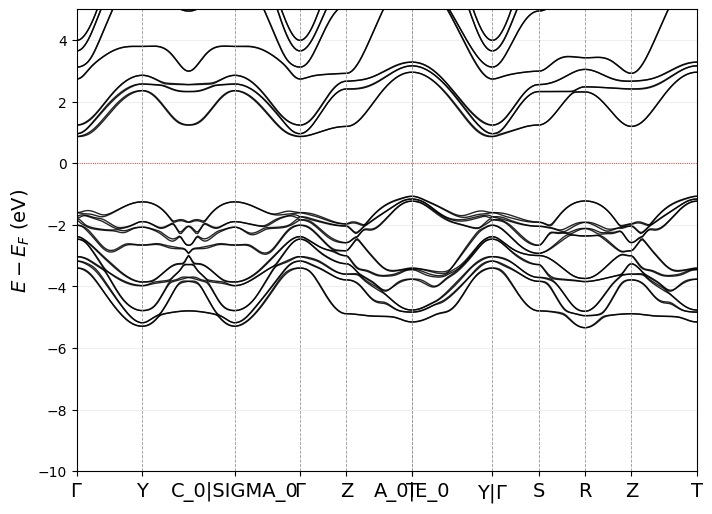

In [9]:
model = tb_model.load("outputs/wannier90_hr.hdf5")

#model.remove_small_hop(1e-5)
#Option to align VBM to zero energy for non-metals following Mat. Proj. convention
#model     = align_to_vbm(model)
fig = bulk_band_structure(model, auto=True, structure=structure,
                          spacing=0.02, e_range=(-10, 5))
fig

Now we plot the charge density on the 001 surface of a 1x1x4 slab

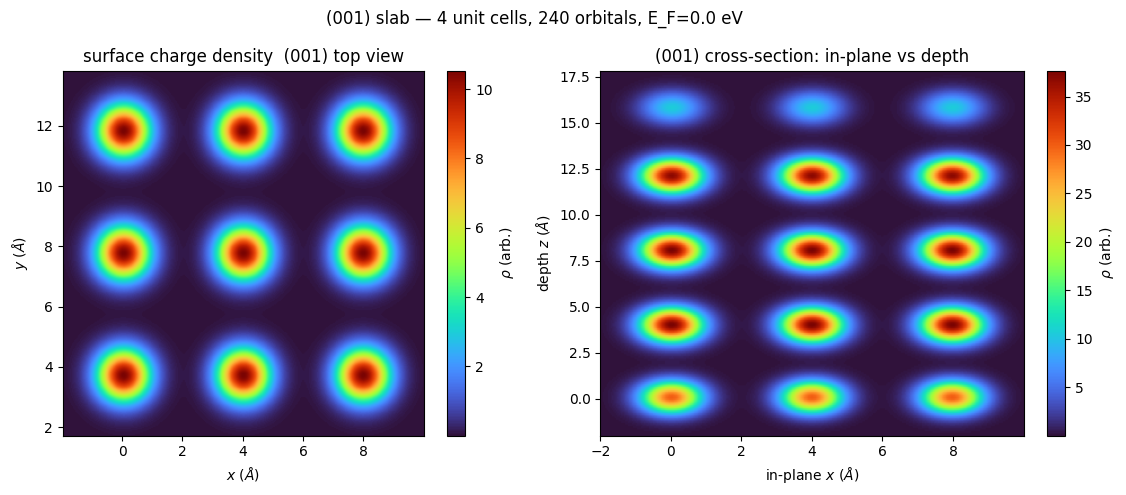

In [15]:
from tailwater import surface_charge_density, load_hr, supercell_self_check


HR_PATH = "outputs/wannier90_hr.hdf5"   # or a Wannier90 *_hr.dat from DFT
MILLER  = (0,0,1)                      # surface Miller index; try (1, 1, 1)
SIZE    = 4                              # slab thickness in unit cells

# 0) Correctness gate — the general-(hkl) integer supercell remap must
#    reproduce the bulk spectrum to machine precision (~1e-13 eV) before
#    any slab built from it is trustworthy.
model = load_hr(HR_PATH)

#err = supercell_self_check(model, MILLER)
#print(f"supercell self-check {MILLER}: {err:.2e} eV  ->  "
#      f"{'OK' if err < 1e-8 else 'FAIL'}")

# 1) Full occupation (E < mu). Returns rho, top_img, side_img, the
#    slab/supercell, and the matplotlib `fig`.
res = surface_charge_density(
    model, MILLER, SIZE,
    mu=0.0,          # Fermi level (eV); 0 = Tailwater training convention
    nk=12,           # nk x nk surface-BZ mesh
    sigma=0.6,       # Gaussian radius (Angstrom) per Wannier centre
    tile=3,          # in-plane unit-cell repetitions in the top view
    show=True,
    savepath="surface_charge_001.png",
)


